# Transfer and extend

Training a normative model on a large reference cohort takes a lot of data and a lot of compute. Rather than training one from scratch, PCNtoolkit lets you take a model that was already trained on tens of thousands of subjects and adapt it to your own, much smaller, dataset. There are two ways to do this: *transfer and extend*.

There is a second reason to work this way. Building a normative model usually means many sites collaborating, but data often cannot leave the hospital or institution where it was collected, because of privacy regulations such as the GDPR. *Extend and transfer* are privacy-preserving, since each site adapts the model locally and shares only the model parameters, never the raw data. The two, however, play different roles: 

- Extend allows the model to be extended sequentially: the first site extends it and passes it to the second, which extends it again, and so on across the consortium. 
- On the other hand, a model should not be transferred sequentially but only once.

## Imports

In [1]:
import warnings
import logging


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    BLR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    plot_centiles_advanced,
)

import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(False)

## Load data

We use the [fcon1000](https://fcon_1000.projects.nitrc.org/fcpClassic/FcpTable.html). This dataset contains derived structural MRI phenotypes from 1,078 subjects collected across 23 sites. To show how transfer and extend work we will split it into two:
- A reference dataset with 21 sites
- a smaller datasets with 2 sites

In [2]:
# Download the dataset
norm_data: NormData = load_fcon1000()

# Select the white matter hypointensities feature
features_to_model = [
    "WM-hypointensities"
]
norm_data = norm_data.sel({"response_vars": features_to_model})

# Leave two sites out for doing transfer and extend later
transfer_sites = ["Milwaukee_b", "Oulu"]
transfer_data, fit_data = norm_data.batch_effects_split({"site": transfer_sites}, names=("transfer", "fit"))

# Split into train and test sets
train, test = fit_data.train_test_split()
transfer_train, transfer_test = transfer_data.train_test_split()

## Visualize the data

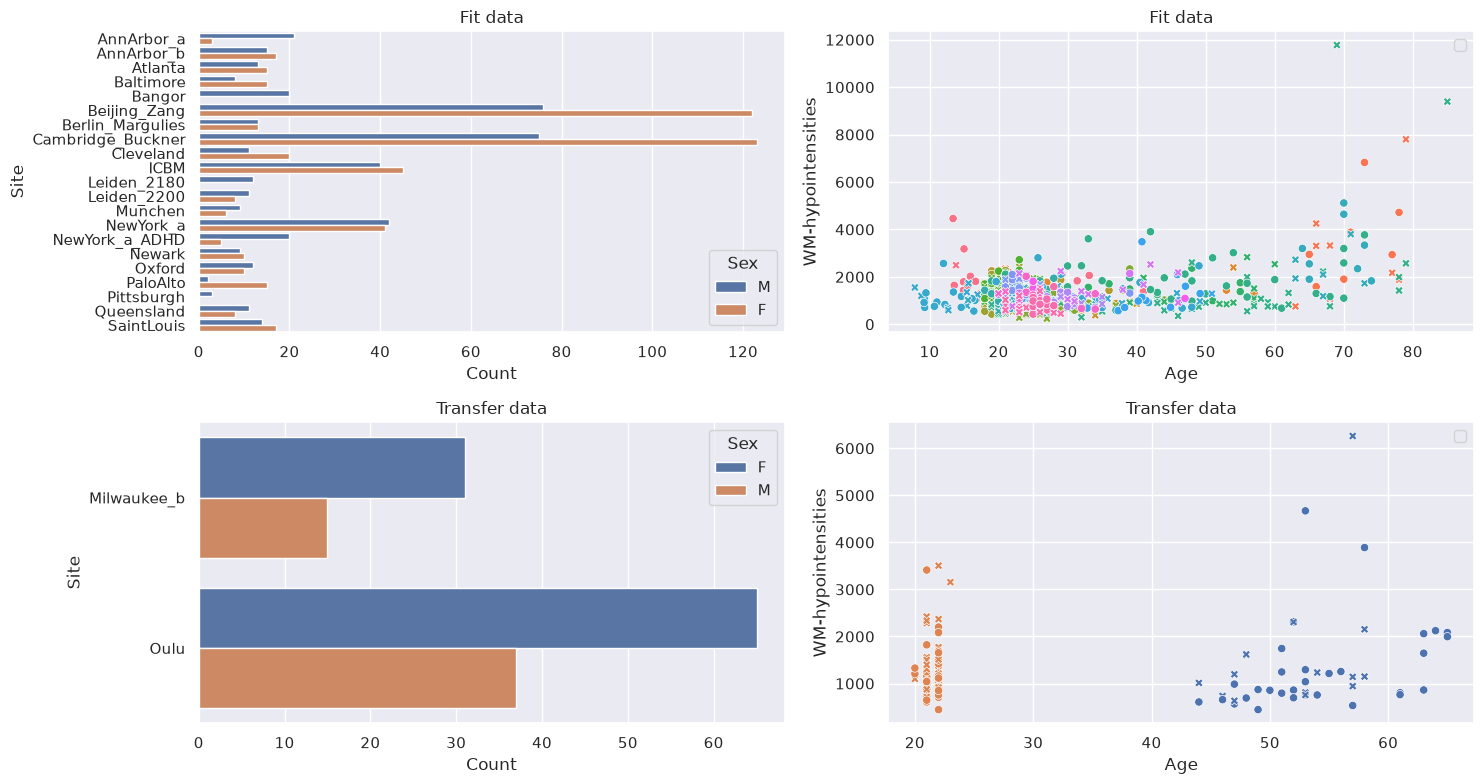

In [3]:
feature_to_plot = features_to_model[0]
datasets = {
    "Fit data": train.merge(test, name="fit"),
    "Transfer data": transfer_train.merge(
        transfer_test, name="transfer"
    ),
}

fig, axes = plt.subplots(
    2, 2, figsize=(15, 8)
)

for i, (name, data) in enumerate(
    datasets.items()
):
    df = data.to_dataframe()
    # Count plot
    sns.countplot(
        data=df,
        y=("batch_effects", "site"),
        hue=("batch_effects", "sex"),
        ax=axes[i, 0],
        orient="h",
    )
    axes[i, 0].legend(title="Sex")
    axes[i, 0].set_title(f"{name}")
    axes[i, 0].set_xlabel("Count")
    axes[i, 0].set_ylabel("Site")

    # Scatter plot
    sns.scatterplot(
        data=df,
        x=("X", "age"),
        y=("Y", feature_to_plot),
        hue=("batch_effects", "site"),
        style=("batch_effects", "sex"),
        ax=axes[i, 1],
    )
    axes[i, 1].legend([], [])
    axes[i, 1].set_title(f"{name}")
    axes[i, 1].set_xlabel("Age")
    axes[i, 1].set_ylabel(feature_to_plot)

plt.tight_layout()
plt.show()

## Normative model

### Create BLR model

In [4]:
template_blr = BLR(
    name="template",
    heteroskedastic=True,
    warp_name="WarpSinhArcsinh",
    basis_function_mean=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    basis_function_var=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)

### Create normative model

In [5]:
model = NormativeModel(
    template_regression_model=template_blr,
    savemodel=False,
    evaluate_model=False,
    saveresults=False,
    saveplots=False,
    inscaler="standardize",
    outscaler="standardize",
)

## Fit normative model on the big reference dataset

We first fit a BLR model on the dataset with 21 sites.

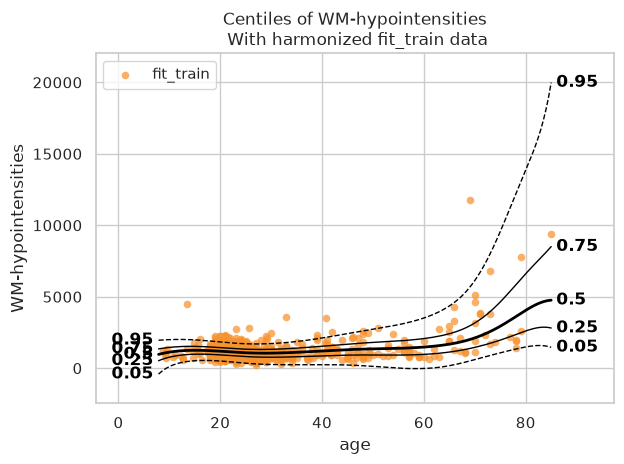

[<Figure size 640x480 with 1 Axes>]

In [6]:
test = model.fit_predict(train, test);

plot_centiles_advanced(
    model,
    scatter_data=train,
    batch_effects = 'all',
    show_legend = False
)

## Fit normative model on the small dataset

And just to show why we prefer extend over just fitting a new model on the small dataset, we can show how bad such a model would be:

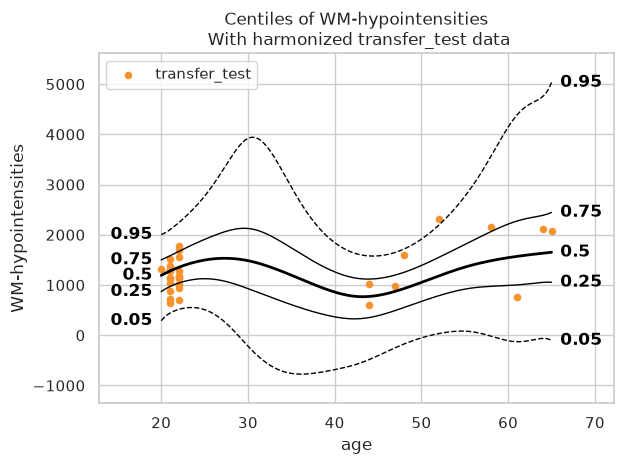

[<Figure size 640x480 with 1 Axes>]

In [7]:
small_model = NormativeModel(
    template_regression_model=template_blr,
    savemodel=True,
    evaluate_model=True,
    saveresults=True,
    saveplots=False,
    save_dir="resources/blr_transfer/save_dir_small",
    inscaler="standardize",
    outscaler="standardize",
)

small_model.fit_predict(transfer_train, transfer_test)

plot_centiles_advanced(
    small_model,
    scatter_data=transfer_test,
    batch_effects='all'
)

The interpolation between ages 22 and 45 is very bad, and that's because there was no train data there.

Now instead, let's extend and transfer to our smaller dataset the big model we fitted earlier, and see how those centiles look.

## Extend

Extend synthesizes data from the central model's learned distribution, merges it with the real local data, and refits a full model.


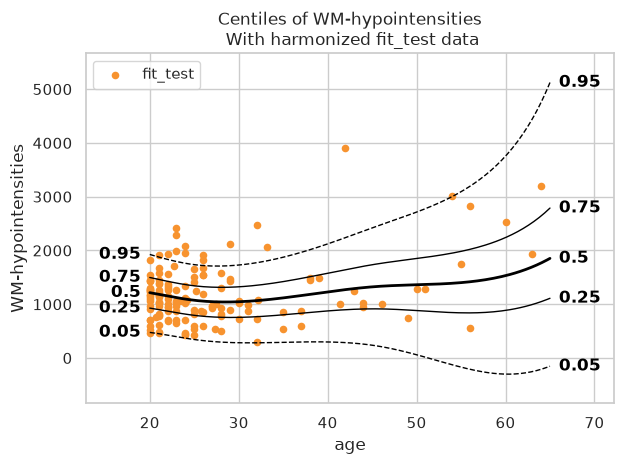

[<Figure size 640x480 with 1 Axes>]

In [8]:
extended_model = model.extend_predict(transfer_train, transfer_test);

plot_centiles_advanced(
    extended_model,
    scatter_data=test,
    batch_effects='all',
    show_legend = False,
    covariate_ranges = {"age": (20, 65)} # for comparison reasons: force the x-axis to be the same as the transfer plot
)

These centiles look much better in comparison to the model we fit on the small dataset (especially at the age range 22-45).

This extended model can be extended again to another dataset. Such an example exists [here](https://github.com/predictive-clinical-neuroscience/pu25_code/blob/main/notebooks/additional_worflows/federated_learning_extend.ipynb).

## Transfer

Transfering looks very similar to extending.

But the underlying mathematics is very different. It adapts a pre-trained reference model to new data by re-estimating parameters *based on prior information derived from the reference model*. 

For this reason, we can _not_ use a transfered model to make predictions on the original train data and a model is not meant to be transferred more than once.

Another consequence is that a transferred model centiles cover the age range present in the data you
transferred to (see x-axis range in the centiles plot below), not the age range of the reference model.

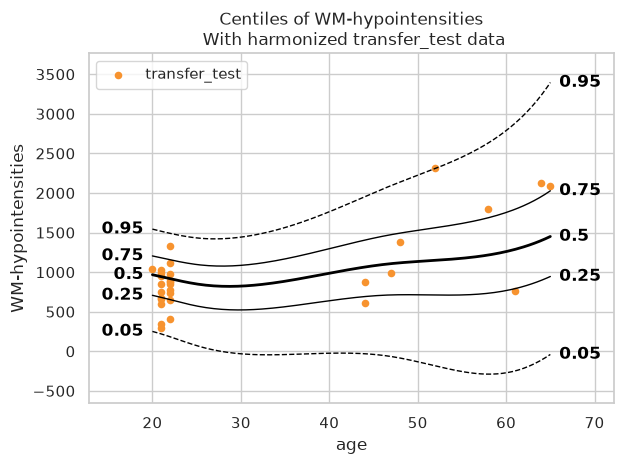

[<Figure size 640x480 with 1 Axes>]

In [9]:
transfered_model = model.transfer_predict(transfer_train, transfer_test);

plot_centiles_advanced(
    transfered_model,
    scatter_data=transfer_test, # note you can not select scatter_data=test as with transfer we lose info about the reference model sites 
    batch_effects='all',
    show_legend = False
)

Similar to extend, we see that the transfered model is also much better than the model we fit on the small dataset (especially at the age range 22-45).  

## Fit normative model on all data

Transfer and extend exist because the data cannot be pooled. But what if it
could? Fitting a single model on all 23 sites at once gives us the reference
point that both methods are trying to approximate.

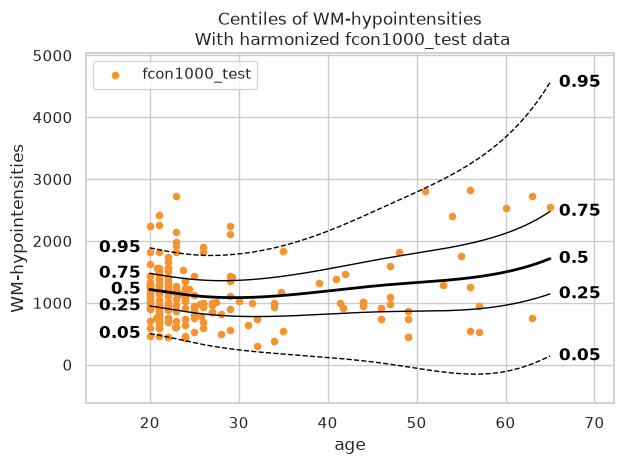

In [10]:
# Split the full dataset (all 23 sites) into train and test
all_train, all_test = norm_data.train_test_split()

pooled_model = NormativeModel(
    template_regression_model=template_blr,
    savemodel=False,
    evaluate_model=False,
    saveresults=False,
    saveplots=False,
    inscaler="standardize",
    outscaler="standardize",
)

pooled_model.fit_predict(all_train, all_test);

plot_centiles_advanced(
    pooled_model,
    scatter_data=all_test,
    batch_effects="all",
    show_legend=False,
    covariate_ranges = {"age": (20, 65)} # for comparison reasons: force the x-axis to be the same as the transfer plot
);